#### 1.订单表的长度，shape，columns
#### 2.统计菜名的平均价格（amounts）
#### 3.什么菜最受欢迎
#### 4.哪个订单ID点的菜最多
#### ...

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl.styles import NamedStyle 
plt.rcParams['font.sans-serif'] = 'SimHei' ## 设置中文显示
%matplotlib inline

# 1.加载数据
data1 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail1')
data2 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail2')
data3 = pd.read_excel('meal_order_detail.xlsx',sheet_name='meal_order_detail3')

# 2.数据预处理（合并数据,NA等处理），分析数据
data = pd.concat([data1,data2,data3],axis=0)  #按照行进行拼接数据
# data.head(5)
data.dropna(axis=1,inplace=True) #按照列删除na列，并且修改源数据data
data
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10037 entries, 0 to 3610
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   detail_id         10037 non-null  int64         
 1   order_id          10037 non-null  int64         
 2   dishes_id         10037 non-null  int64         
 3   dishes_name       10037 non-null  object        
 4   itemis_add        10037 non-null  int64         
 5   counts            10037 non-null  int64         
 6   amounts           10037 non-null  int64         
 7   place_order_time  10037 non-null  datetime64[ns]
 8   add_inprice       10037 non-null  int64         
 9   picture_file      10037 non-null  object        
 10  emp_id            10037 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 941.0+ KB


In [76]:
#统计卖出菜品的平均价格
round(data['amounts'].mean(),2)  #方法一：pandas自带函数
round(np.mean(data['amounts']),2)  #方法二：numpy函数处理

44.82

0 323
1 269
2 239
3 216
4 189
5 188
6 187
7 186
8 178
9 173


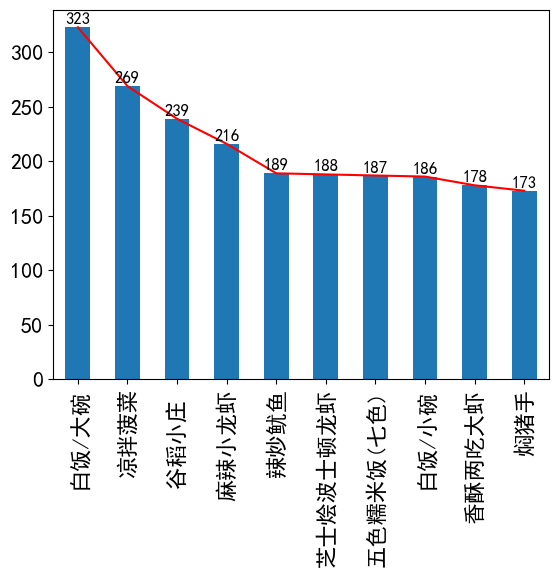

In [77]:
#频数统计，什么菜最受欢迎（对菜名进行频数统计，取最大前10名）
dishes_count = data['dishes_name'].value_counts()[:10]
#3数据可视化matplotlib
dishes_count.plot(kind="line",color=['r'])
dishes_count.plot(kind="bar",fontsize=16)
for x,y in enumerate(dishes_count):
    print(x,y)
    plt.text(x,y+3,y,ha="center",fontsize=12)

Text(0, 0.5, '点菜种类')

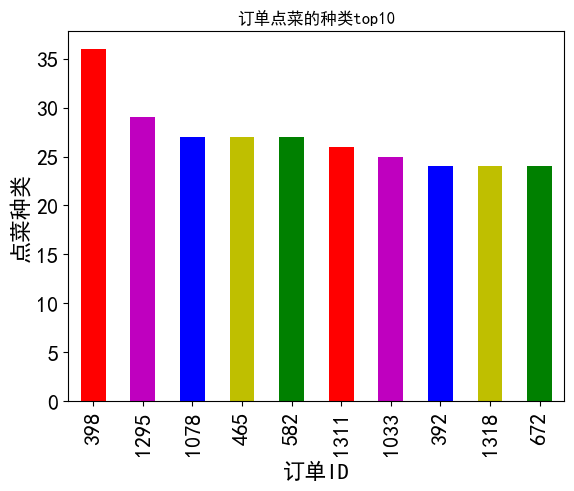

In [78]:
#订单点菜的种类最多（）
data_group = data['order_id'].value_counts()[:10]
data_group.plot(kind="bar",fontsize=16,color=['r','m','b','y','g'])
plt.title('订单点菜的种类top10')
plt.xlabel('订单ID',fontsize=16)
plt.ylabel('点菜种类',fontsize=16)
#8月份餐厅点单点菜种类前10名，平均点菜25个菜品

Text(0, 0.5, '点菜数量')

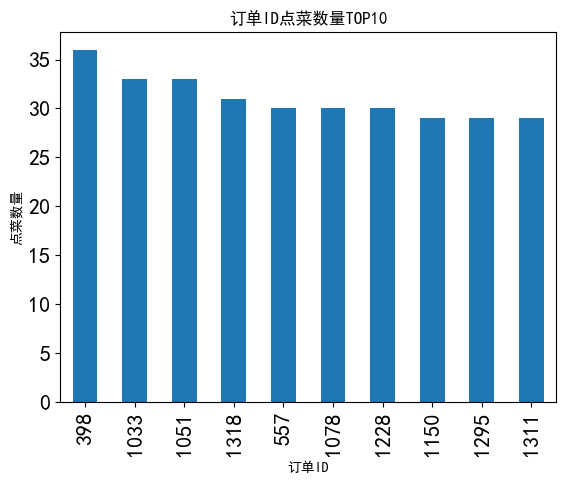

In [79]:
#订单ID点菜数量Top10（分组order_id,counts求和，排序，前十）
data['total_amounts'] = data['counts']*data['amounts'] #统计单道菜消费总额
dataGroup = data[['order_id','counts','amounts','total_amounts']].groupby(by="order_id")
Group_sum = dataGroup.sum() #分组求和
Group_sum
sort_counts = Group_sum.sort_values(by='counts',ascending=False)
sort_counts['counts'][:10].plot(kind="bar",fontsize=16)
plt.title('订单ID点菜数量TOP10')
plt.xlabel('订单ID')
plt.ylabel('点菜数量')

Text(0.5, 1.0, '消费金额前10')

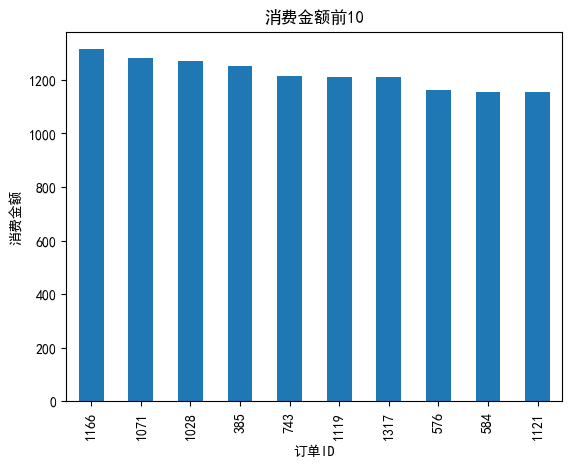

In [80]:
#哪个订单ID吃的钱最多（排序）
sort_total_amounts = Group_sum.sort_values(by="total_amounts",ascending=False)
sort_total_amounts['total_amounts'][:10].plot(kind="bar")
plt.xlabel('订单ID')
plt.ylabel('消费金额')
plt.title('消费金额前10')

,counts,amounts,total_amounts,average
order_id,,,,
168,9,423,1105,122.777778
909,4,471,471,117.750000
418,4,451,451,112.750000
891,7,715,715,102.142857
492,3,301,301,100.333333
...,...,...,...,...
1174,8,110,121,15.125000
632,10,126,140,14.000000
1256,6,77,84,14.000000


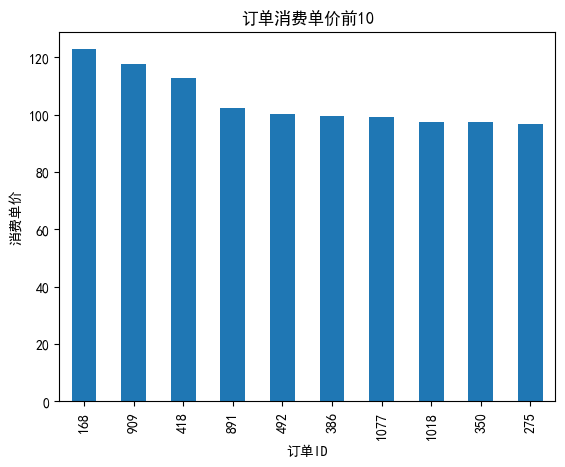

In [81]:
#哪个订单ID平均消费最贵
Group_sum['average'] = Group_sum['total_amounts']/Group_sum['counts']
sort_average = Group_sum.sort_values(by="average",ascending=False)
sort_average['average'][:10].plot(kind="bar")
plt.title('订单消费单价前10')
plt.xlabel('订单ID')
plt.ylabel('消费单价')
sort_average

Text(0, 0.5, '点菜数量')

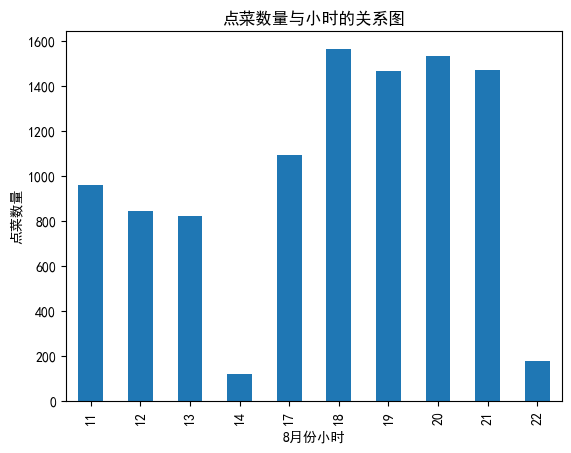

In [82]:
#一天当中什么时间段，点菜量比较集中（hour）
data['hourcount'] = 1
data['time'] = pd.to_datetime(data['place_order_time'])
data['hour'] = data['time'].map(lambda x:x.hour)
gp_by_hour = data.groupby(by='hour').count()['hourcount']
gp_by_hour.plot(kind='bar')
plt.title('点菜数量与小时的关系图')
plt.xlabel('8月份小时')
plt.ylabel('点菜数量')

Text(0, 0.5, '点菜数量')

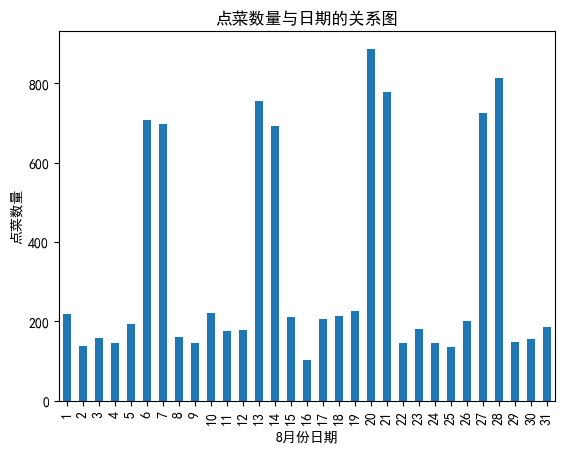

In [83]:
#哪一天订餐数量最多
data['daycount'] = 1
data['day']=data['time'].map(lambda x:x.day)
gp_by_day = data.groupby(by='day').count()['daycount']
gp_by_day.plot(kind='bar')
plt.title('点菜数量与日期的关系图')
plt.xlabel('8月份日期')
plt.ylabel('点菜数量')
#拓展：排序，取点菜数量最大的前5天
# day_sort = gp_by_day.sort_values(ascending=False)[:10]
# day_sort.plot(kind='bar')
# plt.title('点菜数量与日期的关系图')
# plt.xlabel('8月份日期')
# plt.ylabel('点菜数量')

Text(0, 0.5, '点菜数量')

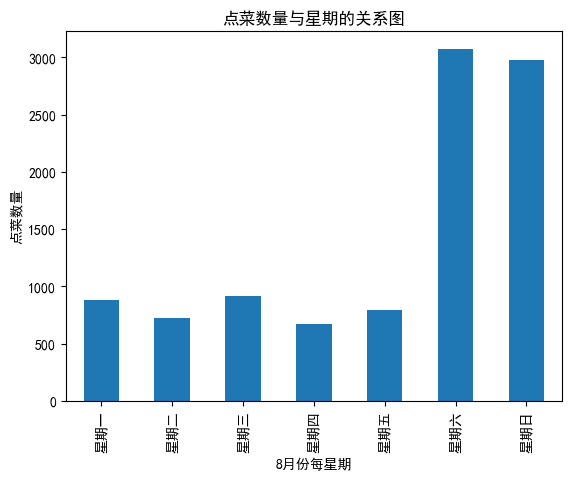

In [84]:
#查看星期几人数最多，订餐数最多，映射数据到星期
data['weekcount'] = 1
week_map = {
    0:'星期一',
    1:'星期二',
    2:'星期三',
    3:'星期四',
    4:'星期五',
    5:'星期六',
    6:'星期日',
}
data['weekday'] = data['time'].map(lambda x:x.weekday())
data['weekdayzh'] = data['weekday'].map(week_map)
gp_by_weekday = data.groupby(by='weekday').count()['weekcount']
gp_by_weekday.index = gp_by_weekday.index.map(week_map)
gp_by_weekday.plot(kind='bar')
plt.title('点菜数量与星期的关系图')
plt.xlabel('8月份每星期')
plt.ylabel('点菜数量')

<AxesSubplot:xlabel='hour'>

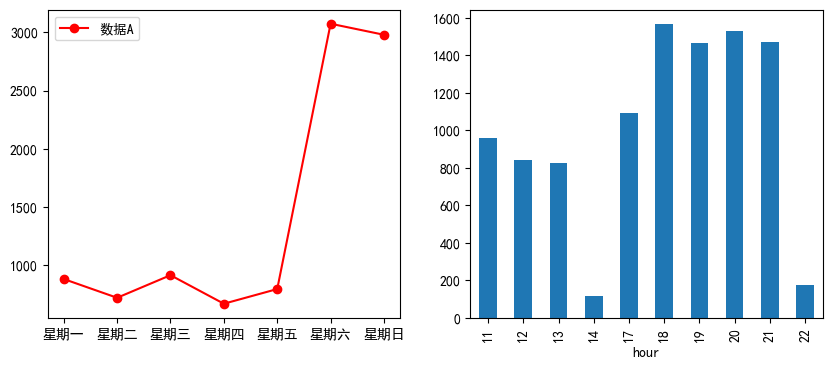

In [85]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(gp_by_weekday,color="red",marker="o",label="数据A")
plt.title('')
plt.legend()
plt.subplot(1,2,2)
gp_by_hour.plot(kind="bar")

In [86]:
data

,detail_id,order_id,dishes_id,dishes_name,itemis_add,counts,amounts,place_order_time,add_inprice,picture_file,emp_id,total_amounts,hourcount,time,hour,daycount,day,weekcount,weekday,weekdayzh
0,2956,417,610062,蒜蓉生蚝,0,1,49,2016-08-01 11:05:36,0,caipu/104001.jpg,1442,49,1,2016-08-01 11:05:36,11,1,1,1,0,星期一
1,2958,417,609957,蒙古烤羊腿,0,1,48,2016-08-01 11:07:07,0,caipu/202003.jpg,1442,48,1,2016-08-01 11:07:07,11,1,1,1,0,星期一
2,2961,417,609950,大蒜苋菜,0,1,30,2016-08-01 11:07:40,0,caipu/303001.jpg,1442,30,1,2016-08-01 11:07:40,11,1,1,1,0,星期一
3,2966,417,610038,芝麻烤紫菜,0,1,25,2016-08-01 11:11:11,0,caipu/105002.jpg,1442,25,1,2016-08-01 11:11:11,11,1,1,1,0,星期一
4,2968,417,610003,蒜香包,0,1,13,2016-08-01 11:11:30,0,caipu/503002.jpg,1442,13,1,2016-08-01 11:11:30,11,1,1,1,0,星期一
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3606,5683,672,610049,爆炒双丝,0,1,35,2016-08-31 21:53:30,0,caipu/301003.jpg,1089,35,1,2016-08-31 21:53:30,21,1,31,1,2,星期三
3607,5686,672,609959,小炒羊腰\r\n\r\n\r\n,0,1,36,2016-08-31 21:54:40,0,caipu/202005.jpg,1089,36,1,2016-08-31 21:54:40,21,1,31,1,2,星期三
3608,5379,647,610012,香菇鹌鹑蛋,0,1,39,2016-08-31 21:54:44,0,caipu/302001.jpg,1094,39,1,2016-08-31 21:54:44,21,1,31,1,2,星期三
3609,5380,647,610054,不加一滴油的酸奶蛋糕,0,1,7,2016-08-31 21:55:24,0,caipu/501003.jpg,1094,7,1,2016-08-31 21:55:24,21,1,31,1,2,星期三


In [91]:
# 为了演示，先把索引变成列（方便合并）
df_week = data.groupby(['weekday','weekdayzh']).count()['weekcount'].reset_index(name="星期统计量")
df_hour = gp_by_hour.reset_index(name="小时统计量")
df_day = gp_by_day.reset_index(name="日统计量")
df_sort_average = sort_average.reset_index()
df_sort_total_amounts = sort_total_amounts.reset_index()
df_sort_counts =sort_counts.reset_index()
df_data_group = data['order_id'].value_counts().reset_index(name="菜量种类")
df_data_group.rename(columns={"index":"order_id"},inplace=True)
df_dishes_count = data['dishes_name'].value_counts().reset_index(name="菜量计量")
df_dishes_count.rename(columns={"index":"order_id"},inplace=True)
data['time'] = pd.to_datetime(data['time'],errors="coerce")
data['datetime'] = data['time'].dt.normalize()
data['datetime'] = data['datetime'].dt.strftime("%Y-%m-%d")
filepath = r"D:\Users\84462\Desktop\数据分析工作\餐饮销售数据\餐饮销售数据源1.xlsx"
with pd.ExcelWriter(filepath, engine="openpyxl") as writer:
    # Sheet 1: 原始明细数据（如果量大，方便后续处理）
    data.to_excel(writer, sheet_name="原始数据", index=False)
    # Sheet 2: 按星期计算结果
    df_week.to_excel(writer, sheet_name="按星期统计", index=False)
    
    # Sheet 3: 按小时计算结果
    df_hour.to_excel(writer, sheet_name="按小时统计", index=False)
     # Sheet 4: 按小时计算结果
    df_day.to_excel(writer, sheet_name="按日期统计", index=False)
     # Sheet 5: #哪个订单ID平均消费最贵
    df_sort_average.to_excel(writer, sheet_name="订单ID平均消费最贵", index=False)
    #哪个订单ID吃的钱最多（排序）
    df_sort_total_amounts.to_excel(writer, sheet_name="订单ID吃的钱最多", index=False)
    #订单ID点菜数量TOP10
    df_sort_counts.to_excel(writer, sheet_name="订单ID点菜数量", index=False)
    #订单点菜的种类最多（）
    df_data_group.to_excel(writer, sheet_name="订单点菜的种类最多", index=False)
    #什么菜最受欢迎（对菜名进行频数统计，取最大前10名）
    df_dishes_count.to_excel(writer, sheet_name="什么菜最受欢迎", index=False)
    
print("✅ 文件导出成功！")

✅ 文件导出成功！
